In [2]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['font.size'] = 12

x0, y0, h, x_end = 0, 0.5, 0.2, 3.0


In [3]:
def exact_solution(x):
    # Тестовое уравнение: y' = y - x^2 + 1, y(0) = 0.5
    # Точное решение: y(x) = (x+1)^2 - 0.5*exp(x)
    return (x+1)**2 - 0.5*np.exp(x)

def f(x, y):
    return y - x**2 + 1

def euler_method(f, x0, y0, x_end, h):
    x = np.arange(x0, x_end + h, h)
    y = np.zeros(len(x))
    y[0] = y0
    for i in range(len(x)-1):
        y[i+1] = y[i] + h * f(x[i], y[i])
    return x, y

def modified_euler(f, x0, y0, x_end, h):
    x = np.arange(x0, x_end + h, h)
    y = np.zeros(len(x))
    y[0] = y0
    for i in range(len(x)-1):
        y_tilde = y[i] + h * f(x[i], y[i])
        y[i+1] = y[i] + h/2 * (f(x[i], y[i]) + f(x[i+1], y_tilde))
    return x, y


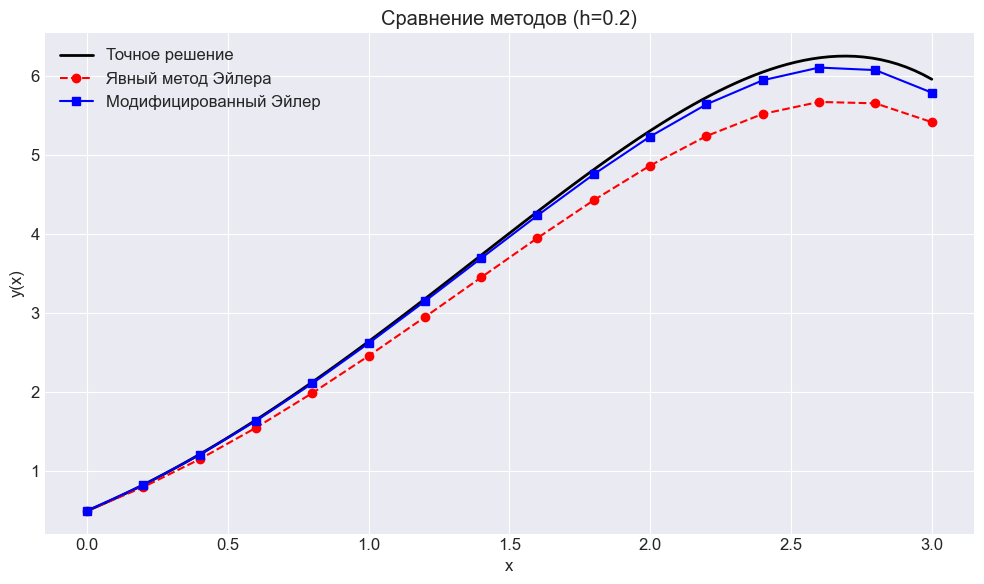

In [4]:
x_exact = np.linspace(x0, x_end, 100)
y_exact = exact_solution(x_exact)
x_e, y_e = euler_method(f, x0, y0, x_end, h)
x_me, y_me = modified_euler(f, x0, y0, x_end, h)

plt.figure(figsize=(10, 6))
plt.plot(x_exact, y_exact, 'k-', linewidth=2, label='Точное решение')
plt.plot(x_e, y_e, 'ro--', label='Явный метод Эйлера')
plt.plot(x_me, y_me, 'bs-', label='Модифицированный Эйлер')
plt.title(f'Сравнение методов (h={h})')
plt.xlabel('x')
plt.ylabel('y(x)')
plt.legend()
plt.tight_layout()
plt.show()
